# Fourier Encoding in PyTorch

In [1]:
import numpy as np
import torch
import torch.nn as nn
from PIL import Image

from models.deep_learning.architectures import MLP
from models.deep_learning.components.embeddings.fourier_encoding import (
    FourierPositionalEncoding as FPE,
)
from models.deep_learning.components.embeddings.visualization import (
    plot_embedding,
    plot_embeddingdims,
)

device = torch.device("mps")

## Definition: Fourier Positional Encoding

A Fourier positional encoding maps each spatial coordinate to a higher-dimensional representation using sinusoidal functions evaluated at a set of frequencies. This provides a continuous and multi-scale encoding of position.

$$
\Phi(x) = \big[ \sin(\omega_k x_i), \cos(\omega_k x_i) \big]_{i=1,\dots,N;\;k=1,\dots,K}
$$

Input
* $x = (x_1, x_2, \dots, x_N) \in \mathbb{R}^N$

Frequencies
* $\omega = (\omega_1, \omega_2, \dots, \omega_K) \in \mathbb{R}^K$

Intermediate Representation
* $z_{i,k} = \omega_k \cdot x_i \in \mathbb{R}$

Output
* $\Phi(x) \in [-1,1]^{2 \cdot N \cdot K}$

Grid Version
* For a spatial grid of shape $(D_1, D_2, \dots, D_N)$ (these are $D_1\cdot D_2 \cdot \dots \cdot D_N$ vectors $x\in \mathbb{R}^N$):
* $\text{coords} \in \mathbb{R}^{D_1 \times \dots \times D_N \times N}$
* $\Phi(\text{coords}) \in [-1,1]^{D_1 \times \dots \times D_N \times (2 \cdot N \cdot K)}$

Then the embedding/encoding dimension is $2 \cdot N \cdot K$.

Interpretation
* Each dimension $x_i$ is encoded independently across multiple frequencies $\omega_k$.

## Dimension 1 (Sequences)

When $N=1$ we get 

$$
\Phi(x) = \big[ \sin(\omega_k x), \cos(\omega_k x) \big]_{k=1,\dots,K}
$$

Input
* $x \in \mathbb{R}$

Frequencies
* $\omega = (\omega_1, \omega_2, \dots, \omega_K) \in \mathbb{R}^K$

Intermediate Representation
* $z_{k} = \omega_k \cdot x \in \mathbb{R}$

Output
* $\Phi(x) \in [-1,1]^{2\cdot K}$

Sequence version
* For a sequence of length $D$: $X=\{x_1,x_2,\dots,x_D\}$.
* $X \in \mathbb{R}^{D}$
* $\Phi(X) \in [-1,1]^{D \times (2 \cdot K)}$

Then the embedding/encoding dimension is $2 \cdot K$.

## Definition: Transformer Sinusoidal Frequencies

The Transformer defines a fixed set of frequencies that follow a geometric progression, enabling the encoding of positions across multiple scales.

$$
\omega_k = \frac{1}{\text{base}^{\frac{2k}{d_{\text{emb}}}}},\quad k = 1,2,\dots ,\frac{d_{\text{emb}}}{2}.
$$

Input
* $i \in \mathbb{Z}_+$

Parameters
* $\text{base} \in \mathbb{R}$ (typically $10000$)
* $d_{\text{emb}} \in \mathbb{N}$ (embedding dimension)

Frequencies
* $\omega = (\omega_1, \omega_2, \dots, \omega_{\frac{d_{\text{emb}}}{2}}) \in \mathbb{R}^{\frac{d_{\text{emb}}}{2}}$

Usage in Positional Encoding
$$
\text{PE}(i) = \big[ \sin(\omega_k \cdot i), \; \cos(\omega_k \cdot i) \big]_{k}, \quad i \in \mathbb{Z}_+ ,\ k = 1,2,\dots ,\frac{d_{\text{emb}}}{2} 
$$

Output
* $\text{PE}(i) \in [-1,1]^{d_{\text{emb}}}, \quad i \in \mathbb{Z}_+ $

In [ ]:
fourier_posenc = FPE(freq=FPE.FPE.transformer_frequency(24, 1)).to(device)
emb = fourier_posenc(spatial_dimensions=(50,))
emb.shape

torch.Size([50, 24])

## Embedding Visualization (per dimension)

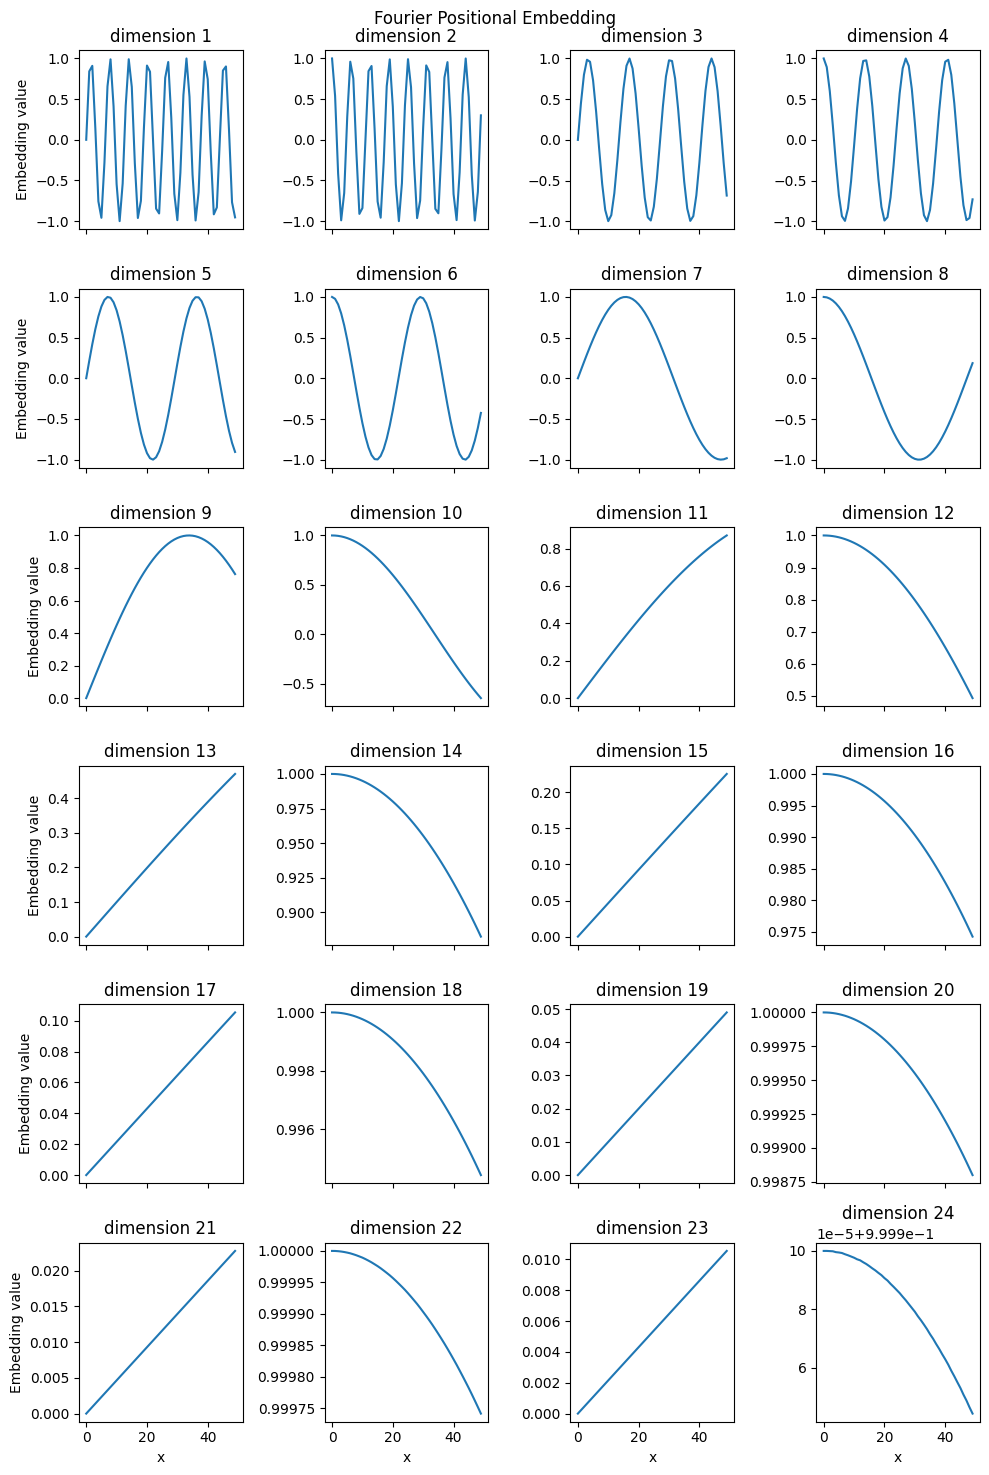

In [3]:
position = FPE.make_coords((50,), torch.device("cpu"))

plot_embeddingdims(position, emb.detach().cpu(), title="Fourier Positional Embedding")

## Embedding Visualization (heat map)

In the 1D case (sequence), this formulation is equivalent to the sinusoidal positional encoding used in the Transformer, as it employs the same frequency scaling.

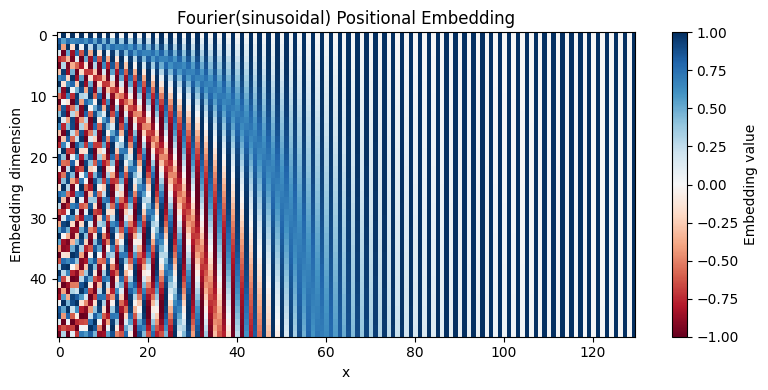

In [4]:
fourier_posenc = FPE(freq=FPE.transformer_frequency(130)).to(device)
emb = fourier_posenc(spatial_dimensions=(50,))

plot_embedding(emb.detach().cpu(), "Fourier(sinusoidal) Positional Embedding")

In [5]:
SM = emb @ emb.T

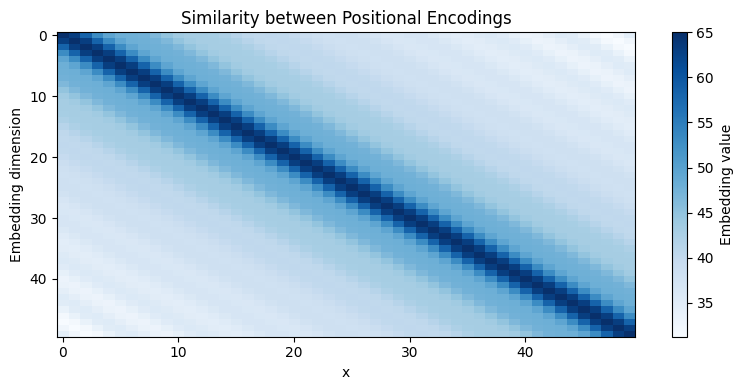

In [6]:
plot_embedding(
    SM.detach().cpu(),
    "Similarity between Positional Encodings",
    cmap="Blues",
    vmin=SM.min(),
    vmax=SM.max(),
)

## Test

Lets learn a figure map (from spatial position to pixel colors)

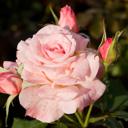

In [7]:
im = Image.open("rose_crop.jpeg").convert("RGB")
im_small = im.resize((128, 128))
im_small

## Learn without positional encoding

In [8]:
rosenet = MLP(input_dim=2, output_dim=3, hidden_dims=[256, 128, 64], activation_cls=nn.ReLU)

In [9]:
rose_tensor = (torch.as_tensor(np.array(im_small), dtype=torch.float32) / 255.0 - 0.5).to(device)
xs = torch.linspace(-1, 1, im_small.size[1])
ys = torch.linspace(-1, 1, im_small.size[0])

norm_position = torch.stack(
    torch.meshgrid(ys, xs, indexing="ij"),
    dim=-1,
).to(device)
norm_position.shape

torch.Size([128, 128, 2])

## Training

In [10]:
net = rosenet.to(device)
optim = torch.optim.Adam(net.parameters(), lr=1e-3)

for it in range(5000):
    optim.zero_grad()
    loss = abs(net(norm_position) - rose_tensor).mean()
    loss.backward()
    optim.step()
    if it % 100 == 0:
        print(f"Iteration {it}, loss: {loss.item():.6f}")

Iteration 0, loss: 0.310872
Iteration 100, loss: 0.107805
Iteration 200, loss: 0.087205
Iteration 300, loss: 0.079555
Iteration 400, loss: 0.075254
Iteration 500, loss: 0.073159
Iteration 600, loss: 0.068968
Iteration 700, loss: 0.067261
Iteration 800, loss: 0.067433
Iteration 900, loss: 0.065310
Iteration 1000, loss: 0.062526
Iteration 1100, loss: 0.063385
Iteration 1200, loss: 0.062516
Iteration 1300, loss: 0.059990
Iteration 1400, loss: 0.060458
Iteration 1500, loss: 0.057596
Iteration 1600, loss: 0.058283
Iteration 1700, loss: 0.056362
Iteration 1800, loss: 0.055406
Iteration 1900, loss: 0.054801
Iteration 2000, loss: 0.054041
Iteration 2100, loss: 0.056004
Iteration 2200, loss: 0.053035
Iteration 2300, loss: 0.053191
Iteration 2400, loss: 0.052469
Iteration 2500, loss: 0.055744
Iteration 2600, loss: 0.055550
Iteration 2700, loss: 0.051972
Iteration 2800, loss: 0.052255
Iteration 2900, loss: 0.053088
Iteration 3000, loss: 0.052976
Iteration 3100, loss: 0.051112
Iteration 3200, loss

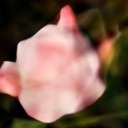

In [11]:
Image.fromarray(
    ((net(norm_position) + 0.5).clamp(0, 1).cpu().detach().numpy() * 255).astype(np.uint8)
)

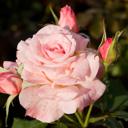

In [12]:
im_small

## Training with Sinusoidal positional encoding

In [13]:
emb_dim = 16
fourier_posenc = FPE(freq=FPE.transformer_frequency(emb_dim, ndim=2)).to(device)
rosenet = MLP(
    input_dim=emb_dim, output_dim=3, hidden_dims=[256, 128, 64], activation_cls=nn.ReLU
).to(device)
fourier_posenc(spatial_dimensions=im_small.size).shape

torch.Size([128, 128, 16])

In [14]:
rose_tensor = rose_tensor.to(device)
optim = torch.optim.Adam(rosenet.parameters(), lr=1e-3)

for it in range(5000):
    optim.zero_grad()
    loss = abs(rosenet(fourier_posenc(im_small.size)) - rose_tensor).mean()
    loss.backward()
    optim.step()
    if it % 100 == 0:
        print(f"Iteration {it}, loss: {loss.item():.6f}")

Iteration 0, loss: 0.333517
Iteration 100, loss: 0.097873
Iteration 200, loss: 0.071317
Iteration 300, loss: 0.061988
Iteration 400, loss: 0.059146
Iteration 500, loss: 0.053117
Iteration 600, loss: 0.048932
Iteration 700, loss: 0.048022
Iteration 800, loss: 0.048894
Iteration 900, loss: 0.047840
Iteration 1000, loss: 0.043121
Iteration 1100, loss: 0.039838
Iteration 1200, loss: 0.040592
Iteration 1300, loss: 0.037406
Iteration 1400, loss: 0.039576
Iteration 1500, loss: 0.035132
Iteration 1600, loss: 0.035831
Iteration 1700, loss: 0.036406
Iteration 1800, loss: 0.034032
Iteration 1900, loss: 0.034430
Iteration 2000, loss: 0.033644
Iteration 2100, loss: 0.031525
Iteration 2200, loss: 0.031897
Iteration 2300, loss: 0.030539
Iteration 2400, loss: 0.031048
Iteration 2500, loss: 0.029504
Iteration 2600, loss: 0.029812
Iteration 2700, loss: 0.030612
Iteration 2800, loss: 0.027590
Iteration 2900, loss: 0.029228
Iteration 3000, loss: 0.028411
Iteration 3100, loss: 0.028734
Iteration 3200, loss

In [15]:
img_gen = rosenet(fourier_posenc(im_small.size)).detach().cpu()
img_gen.shape

torch.Size([128, 128, 3])

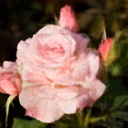

In [16]:
Image.fromarray(((img_gen + 0.5).clamp(0, 1).cpu().detach().numpy() * 255).astype(np.uint8))

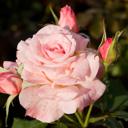

In [17]:
im_small

## Generalization (bigger image)

In [18]:
img_gen = rosenet(fourier_posenc(im_small.size, sampling_factor=8))
img_gen.shape

torch.Size([1024, 1024, 3])

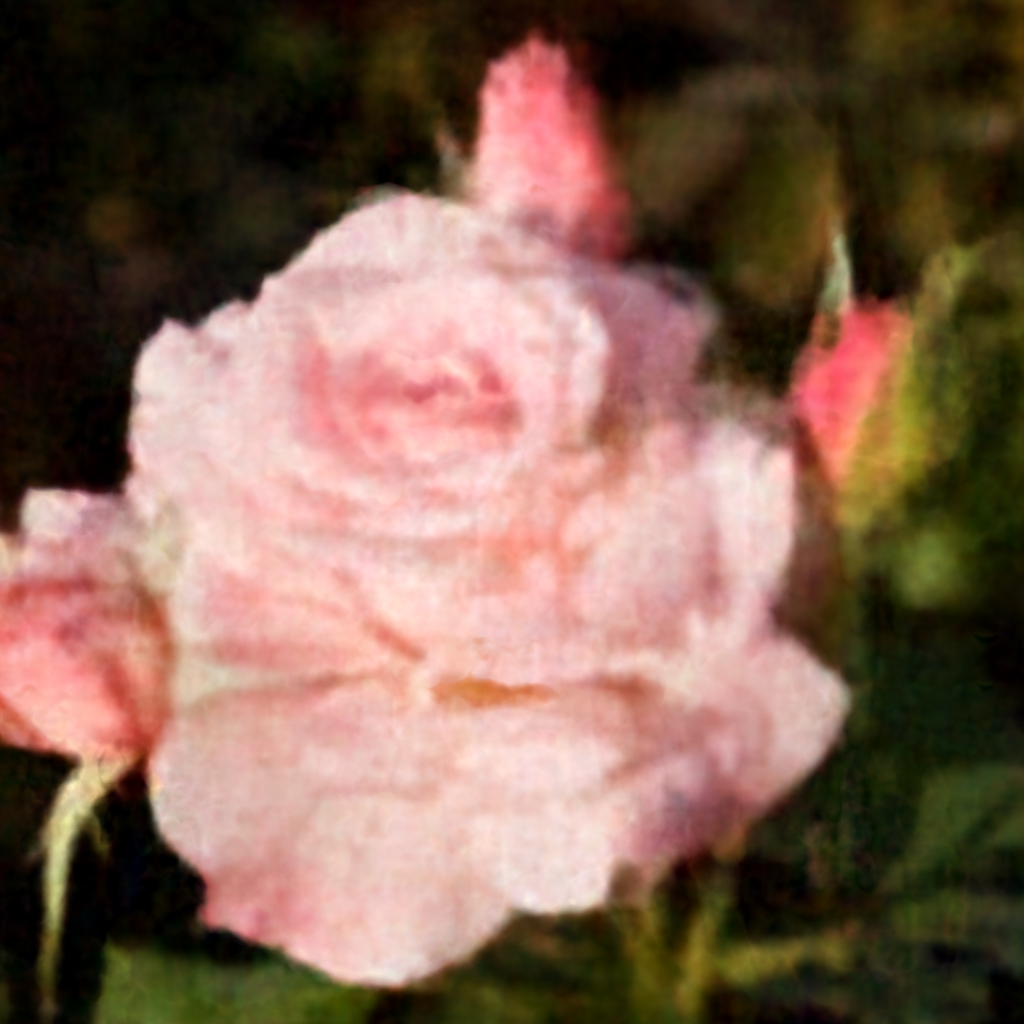

In [19]:
Image.fromarray(((img_gen + 0.5).clamp(0, 1).cpu().detach().numpy() * 255).astype(np.uint8))

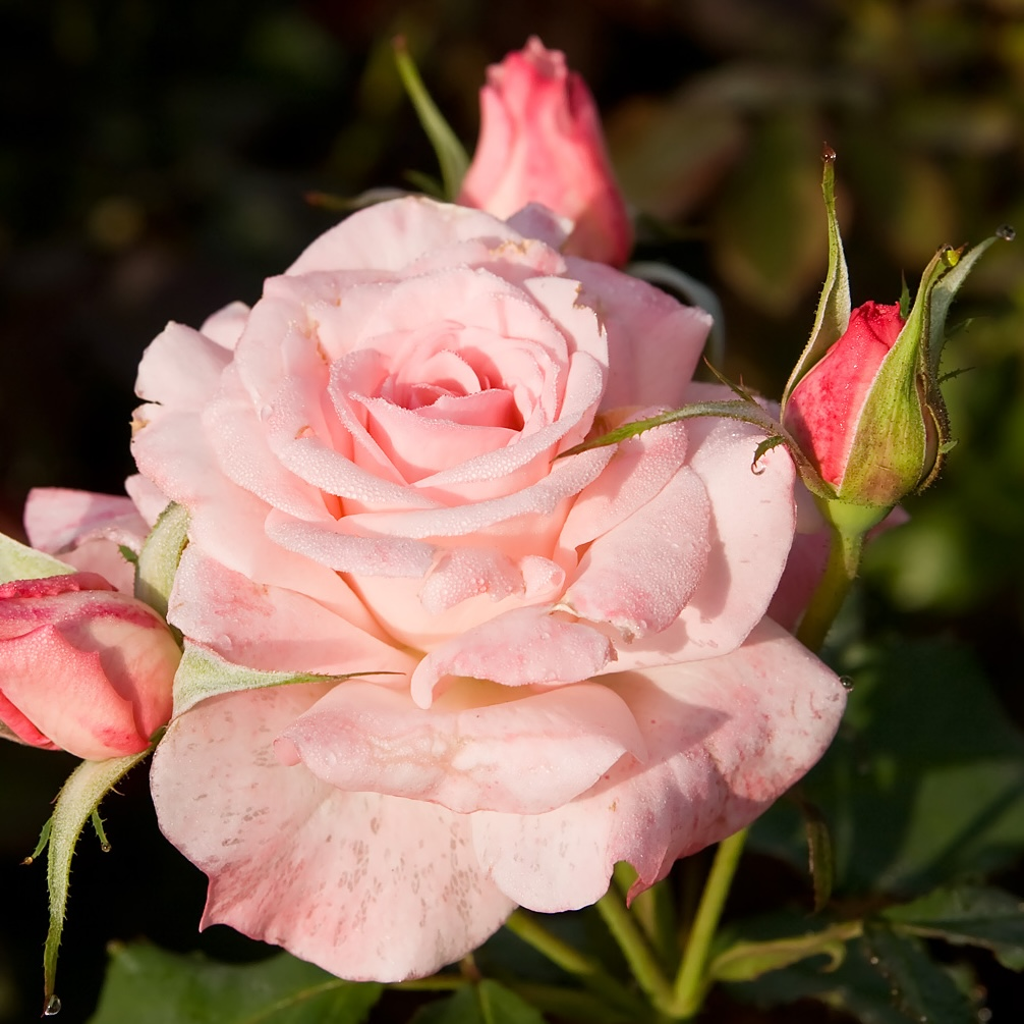

In [20]:
im.resize((1024, 1024))

In [21]:
enb_flat = fourier_posenc(im_small.size).flatten(end_dim=1)
enb_flat.shape

torch.Size([16384, 16])

In [22]:
im_small.size

(128, 128)

## Flatten similarity

After flattening the spatial dimensions, long-range correlations become more visible: sinusoidal encodings capture local positional differences well, but their periodic nature introduces global ambiguities, causing distant positions to appear similar.

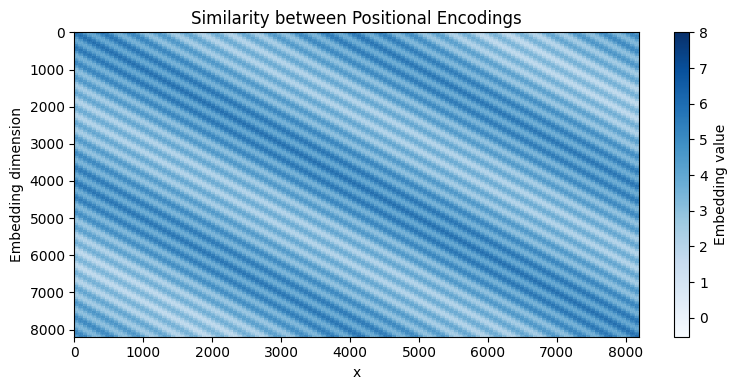

In [23]:
SM = enb_flat @ enb_flat.T
sm = SM[::2, ::2]
plot_embedding(
    sm.detach().cpu(),
    "Similarity between Positional Encodings",
    cmap="Blues",
    vmin=sm.min(),
    vmax=sm.max(),
)